In [1]:
%reload_ext autoreload
%autoreload 2
from importlib import reload

import os
import sys
import pickle
import logging
import warnings
import numpy as np
import astropy as ap
import scipy as sp
import scipy.stats
import matplotlib as mpl
import matplotlib.pyplot as plt

import h5py
import tqdm.notebook as tqdm

import kalepy as kale
import kalepy.utils
import kalepy.plot

import holodeck as holo
import holodeck.sams
import holodeck.gravwaves
from holodeck import cosmo, utils, plot, discrete, sams, host_relations, _PATH_DATA
from holodeck.constants import MSOL, PC, YR, MPC, GYR, SPLC, SCHW, NWTG
from pathlib import Path
from compare_sams import load_sams_from_pkl,calc_sam_dadt_from_pkl,calc_total_tau_inner
from compare_sams import plot_dadt, calc_aGW_for_Fixed_Time_2PL,calc_cumulative_thard

# Silence annoying numpy errors
np.seterr(divide='ignore', invalid='ignore', over='ignore')
warnings.filterwarnings("ignore", category=UserWarning)

# Plotting settings
mpl.rc('font', **{'family': 'serif', 'sans-serif': ['Times'], 'size': 15})
mpl.rc('lines', solid_capstyle='round')
mpl.rc('mathtext', fontset='cm')
plt.rcParams.update({'grid.alpha': 0.5})
mpl.style.use('default')   # avoid dark backgrounds from dark theme vscode

log = holo.log
log.setLevel(logging.INFO)


# ---- Define filepath containing simulation galaxy merger data files ----#
# ---- (if using files not in _PATH_DATA) ---- #
_HOME_PATH = Path('~/').expanduser()
#p = os.path.join(_HOME_PATH, 'cosmo_sim_merger_data')
p = os.path.join(_HOME_PATH, 'nanograv/gensams')
#p = os.path.join(_HOME_PATH, 'holodeck/holodeck/data')
if os.path.exists(p):
    _SIM_MERGER_PATH = p
else:
    p = os.path.join(_HOME_PATH, 'nanograv/cosmo_sim_merger_data')
    if os.path.exists(p):
        _SIM_MERGER_PATH = p
    else:
        _SIM_MERGER_PATH = _PATH_DATA
#_SIM_MERGER_PATH = _PATH_DATA
print(f"{_SIM_MERGER_PATH=}")
# ------------------------------------------------------------------------ #


_SIM_MERGER_PATH='/Users/lblecha/nanograv/gensams'


## GWB Spectrum Plot

In [39]:
def calc_hctot(gwb_sam):
    return np.sqrt( np.sum(gwb_sam[0]**2,axis=2) + gwb_sam[1]**2 )

def __plot_gwb(fobs, gwb, hc_ss=None, bglabel=None, sslabel=None, **kwargs):
    xx = fobs * YR
    fig, ax = figax(
        xlabel=LABEL_GW_FREQUENCY_YR,
        ylabel=LABEL_CHARACTERISTIC_STRAIN
    )
    if(hc_ss is not None):
        draw_ss_and_gwb(ax, xx, hc_ss, gwb, sslabel=sslabel,
                        bglabel=bglabel, **kwargs)
    else:
        draw_gwb(ax, xx, gwb, **kwargs)
    _twin_hz(ax)
    return fig

def __draw_gwb(ax, xx, gwb, nsamp=10, color=None, label=None, ls=None, lw=None,
               alpha=0.25, **kwargs):
    if color is None:
        color = ax._get_lines.get_next_color()
    if ls is None:
        ls = '-'
    if lw is None: 
        lw=1.0
    kw_plot = kwargs.pop('plot', {})
    kw_plot.setdefault('color', color)
    #print(f"in __draw_gwb() call:{lw=} {ls=} {alpha=}")    
    hh = __draw_med_conf(ax, xx, gwb, plot=kw_plot, label=label, lw=lw, ls=ls, **kwargs)
    if (nsamp is not None) and (nsamp > 0):
        nsamp_max = gwb.shape[1]
        idx = np.random.choice(nsamp_max, np.min([nsamp, nsamp_max]), replace=False)
        for ii in idx:
            ax.plot(xx, gwb[:, ii], color=color, alpha=alpha, lw=lw, ls=ls)

    return hh

def __draw_med_conf(ax, xx, vals, fracs=[0.50, 0.90], weights=None, plot={}, 
                    fill={}, filter=False, label=None, lw=1.0, ls='-'):
    #plot.setdefault('alpha', 0.75)
    #fill.setdefault('alpha', 0.2)
    plot.setdefault('alpha', 0.9)
    fill.setdefault('alpha', 0.1)
    percs = np.atleast_1d(fracs)
    assert np.all((0.0 <= percs) & (percs <= 1.0))

    # center the target percentages into pairs around 50%, e.g.  68 ==> [16,84]
    inter_percs = [[0.5-pp/2, 0.5+pp/2] for pp in percs]
    # Add the median value (50%)
    inter_percs = [0.5, ] + np.concatenate(inter_percs).tolist()
    # Get percentiles; they go along the last axis
    if filter:
        rv = [
            kale.utils.quantiles(vv[vv > 0.0], percs=inter_percs, weights=weights)
            for vv in vals
        ]
        rv = np.asarray(rv)
    else:
        rv = kale.utils.quantiles(vals, percs=inter_percs, weights=weights, axis=-1)

    med, *conf = rv.T
    # plot median
    hh, = ax.plot(xx, med, **plot, lw=lw, ls=ls, label=label)

    # Reshape confidence intervals to nice plotting shape
    # 2*P, X ==> (P, 2, X)
    conf = np.array(conf).reshape(len(percs), 2, xx.size)

    kw = dict(color=hh.get_color())
    kw.update(fill)
    fill = kw

    # plot each confidence interval
    for lo, hi in conf:
        gg = ax.fill_between(xx, lo, hi, **fill)

    return (hh, gg)

def invyr2hz(invyr):
    return invyr / YR
def hz2invyr(hz):
    return hz * YR
    
def compare_gwb_sams(sams, var_type=None, fid_value=None, gpf_flags=None, fpath='', 
                     save=True, fname_extra='', show_title=True, cmap_arr=None,
                     linestyles=None, ylim=(2.0e-17,2.0e-14), #ylim=(2.0e-16,8.0e-15), 
                     colors=None, lbl_extra=None, sam_colors=None,sam_lbls=None,
                     NLOUD=None, NREALS=None, TAU=None):

    valid_models = 0
    for s in sams:
        if s.gwb_sam is not None:
            valid_models += 1
    if valid_models == 0:
        log.warning("No elements in sam data had a valid gwb. Nothing to plot.")
        return
        
    LABEL_GW_FREQUENCY_YR = r"GW Frequency $[\mathrm{yr}^{-1}]$"
    LABEL_GW_FREQUENCY_HZ = r"GW Frequency $[\mathrm{Hz}]$"
    LABEL_GW_FREQUENCY_NHZ = r"GW Frequency $[\mathrm{nHz}]$"
    LABEL_SEPARATION_PC = r"Binary Separation $[\mathrm{pc}]$"
    LABEL_CHARACTERISTIC_STRAIN = r"GW Characteristic Strain"
    LABEL_HARDENING_TIME = r"Hardening Time $[\mathrm{Gyr}]$"
    LABEL_CLC0 = r"$C_\ell / C_0$"

    freq_min = np.min(sams[0].PARS['freqs'])*0.95
    freq_max = np.max(sams[0].PARS['freqs'])*1.05
    print(f"{freq_min=} {freq_max=}")
    _freqs, _freqs_edges = utils.pta_freqs()
    print(f"{_freqs.min()=} {_freqs.max()=}")
    print(f"{_freqs_edges.min()=} {_freqs_edges.max()=}")
    
    fig, ax = plot.figax(
        xlabel=LABEL_GW_FREQUENCY_YR,
        ylabel=LABEL_CHARACTERISTIC_STRAIN,
        xlim=(freq_min*YR,freq_max*YR),
        ylim=ylim,
        figsize=(6,5)
    )
    secax = ax.secondary_xaxis('top', functions=(invyr2hz, hz2invyr),xlabel=LABEL_GW_FREQUENCY_HZ)

    if cmap_arr is None:
        cm = plot._get_cmap('viridis')
        colors = cm(np.linspace(0, 1, len(sams)))
    else:
        if len(cmap_arr) != len(sams):
            raise ValueError("len(cmap_arr) must match len(sams) if not None")
    colors_list = []
    
    frac = 0.50
    
    print(f"{len(sams)=}")
    if len(sams) > 0:
        sam_freqs = sams[0].PARS['freqs']
        xx = sam_freqs * YR

        idx_fiducial = None
        for n,s in enumerate(sams):

            if cmap_arr is not None:
                cm = plot._get_cmap(cmap_arr[n])
                #colors = cmap(np.linspace(0.3, 1, max_to_plot+1))
                colors_list.append(cm(0.8))
            else:
                colors_list.append(colors[n])
                
            if s.gwb_sam is None:
                print("no plot generated for sam with invalid params:")
                continue
            
            if var_type is not None and fid_value is not None:
                if var_type=='hard_r_gw_crit_9' or var_type=='hard_rchar_9':
                    par = np.log10(s.PARS[var_type])
                else:
                    par = s.PARS[var_type]
                if np.abs(fid_value-par) < 1.0e-6:
                    idx_fiducial = n
            
            if sam_lbls is not None and len(sam_lbls)==len(sams):
                lbl = sam_lbls[n]
            else:
                lbl = ''
                if lbl_extra is not None:
                    if len(lbl_extra) == len(sams):
                        lbl += lbl_extra[n]

            if colors_list is not None and len(colors_list)>=len(sams):
                thiscol = colors_list[n]
            else:
                thiscol = 'k'
            lw = (len(sams)-n)*0.2 + 0.8
            if sam_lbls is not None:
                print(f"{n=} {sam_lbls[n]=}")
                lw += 1.2
                _al = 0.6
                if linestyles is not None and len(linestyles)==len(sams):
                    ls = linestyles[n]
                else:
                    ls='-' if n==0 else '--'
            else:
                ls = '-' if n==idx_fiducial else '--'
                _al = 0.5 if n==idx_fiducial else 0.05
                if n==idx_fiducial: lw += 2

            
            s_hctot = calc_hctot(s.gwb_sam)
            if n==idx_fiducial:
                __draw_gwb(ax, xx, s_hctot, nsamp=0, color=colors_list[n], label=lbl,
                           lw=lw, ls=ls, alpha=_al, fracs=[frac])
            else:
                __draw_gwb(ax, xx, s_hctot, nsamp=0, color=colors_list[n], label=lbl,
                           lw=lw, ls=ls, alpha=_al, fracs=[frac])

    if sam_lbls is not None:
        legend_title='Model type'
    else:
        if var_type=='hard_r_gw_crit_9':
            legend_title=r'a$_{\rm GW,9}$ [${\rm R_g}$]'
        elif var_type=='hard_alpha_gw_crit':
            legend_title=r'$\alpha_{\rm GW}$'
        elif var_type=='hard_beta_gw_crit':
            legend_title=r'$\beta_{\rm GW}$'
        elif var_type=='hard_rchar_9':
            legend_title=r'a$_{\rm char,9}$ [pc]'
        elif var_type=='hard_nu_inner':
            legend_title=r'$\nu_{\rm inner}$'
        elif var_type=='hard_outer_time':
            legend_title=r'$\tau_{\rm out}$ [Gyr]'
        else: 
            legend_title=""  
        
    plt.legend(loc='lower left',fontsize=10,title=legend_title) 

    if show_title:
        if 'new_hard' in fname_extra or 'newhard' in fname_extra:
            suptitl = (f"{fname_extra}\n"
                         +f"tout={s.PARS['hard_outer_time']:.2g}, "
                         +f"rch9={s.PARS['hard_rchar_9']:.2g}pc, "
                         +f"alphch={s.PARS['hard_alpha_char']:.2g}, "       
                         +f"rgw9={s.PARS['hard_r_gw_crit_9']:.2g}{s.PARS['hard_gw_crit_units']}, "
                         +f"alphgw={s.PARS['hard_alpha_gw_crit']:.2g}, ")
            if s.hard._inner_model_type == 0:
                suptitl += f"nuin={s.PARS['hard_nu_inner']:.2g}"
            elif s.hard._inner_model_type == 1:
                suptitl += f"dadt={s.PARS['hard_dadt_rchar']:.2g}"
            else:
                raise NotImplementedError
            plt.suptitle(suptitl)
        else:
            plt.suptitle(fname_extra)

    plt.tight_layout()
    
    if save:
        if fname_extra != '':
            fname = f'gwb_compare_nloud{NLOUD}_nreals{NREALS}_{fname_extra}.png'
        else:
            fname = f'gwb_compare_nloud{NLOUD}_nreals{NREALS}.png'            
        plt.savefig(f"{fpath}/{fname}", dpi=300)

    return

## tau_inner plots

In [85]:
def plot_tau_inner(sams, fname_extra='', xvar='rgw9', fid_value=2.5, max_q_to_plot=4,
                   NREALS=None, NLOUD=None, show_title=True, fpath='', horizontal=True,
                   figwidth=4,figheight=5,
                   cmap_arr=None, idx_to_plot=None, save=True):

    if horizontal:
        fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(7,3))
    else:
        fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(figwidth,figheight))
        
    if cmap_arr is None:
        cm = plot._get_cmap('viridis')
        colors = cm(np.linspace(0, 1, len(sams)))
    else:
        if len(cmap_arr) != len(sams):
            raise ValueError("len(cmap_arr) must match len(sams) if not None")
    colors_list = []

    xvals = []
    lgt7_list = []
    lgt9_list = []
    lgt11_list = []
    marker_list = []
    idx_fiducial = None
    idx_invalid = []
    if idx_to_plot is None:
        idx_to_plot = [0,len(sams)-1]
        
    for n,s in enumerate(sams):

        if s.gwb_sam is None:
            print(f"{n=} {s.gwb_sam=}")
            colors_list.append('gray')
            mrk='x'
            idx_invalid.append(n)
        else:
            if cmap_arr is not None:
                cm = plot._get_cmap(cmap_arr[n])
                #colors = cmap(np.linspace(0.3, 1, max_to_plot+1))
                colors_list.append(cm(0.7))
            else:
                colors_list.append(colors[n])
            mrk='o'
        marker_list.append(mrk)
        lw = np.arange(0.5,max_q_to_plot+1, 0.5)
        ls = [':','-','-.','--']
        
        mt, mr, = np.broadcast_arrays(
            s.sam.mtot[:, np.newaxis],
            s.sam.mrat[np.newaxis, :]
        )

        ix7 = np.where(np.abs(s.sam.mtot/MSOL-1e7)==np.min(np.abs(s.sam.mtot/MSOL-1e7)))[0]
        ix9 = np.where(np.abs(s.sam.mtot/MSOL-1e9)==np.min(np.abs(s.sam.mtot/MSOL-1e9)))[0]
        ix11 = np.where(np.abs(s.sam.mtot/MSOL-1e11)==np.min(np.abs(s.sam.mtot/MSOL-1e11)))[0]
        tau_in, rgw_crit = calc_total_tau_inner(s.hard, mt, mr)
        lgt7_list.append(np.log10(tau_in[ix7,-1]/YR))
        lgt9_list.append(np.log10(tau_in[ix9,-1]/YR))
        lgt11_list.append(np.log10(tau_in[ix11,-1]/YR))
        
        if xvar=='rgw9':
            xval=np.log10(s.hard._r_gw_crit_9)
            xlbl = r'log$_{\rm 10}$(a$_{\rm GW,9}/{\rm R_g}$)'            
        elif xvar=='nui':
            xval=s.hard._nu_inner
            xlbl = r'$\nu_{\rm inner}$'
        elif xvar=='alphgw':
            xval=s.hard._alpha_gw_crit
            xlbl = r'$\alpha_{\rm GW}$'
        elif xvar=='betagw':
            xval=s.hard._beta_gw_crit
            xlbl = r'$\beta_{\rm GW}$'
        elif xvar=='rch9':
            xval=np.log10(s.hard._rchar_9/PC)
            xlbl = r'log$_{\rm 10}$(a$_{\rm char,9}$/pc)'
        elif xvar=='tout':
            xval=np.log10(s.hard._outer_time/GYR)
            xlbl = r'$\tau_{\rm out}$ [Gyr]' 
        else:
            raise ValueError()

        xvals.append(xval)
        if np.abs(xval-fid_value) < 1.0e-6:
            idx_fiducial = n
            if n not in idx_to_plot:
                idx_to_plot.append(n)

        axs[0].set_xlabel(xlbl)
        axs[0].set_ylabel(r'log$_{\rm 10}$($\tau_{\rm in+gw}/{\rm yr}$)')
        axs[0].set_ylim(2,14)
        axs[1].set_xlabel(r'log$_{10}$(M/M$_{\odot}$)')
        if not horizontal:
            axs[1].set_ylabel(r'log$_{\rm 10}$($\tau_{\rm in+gw}/{\rm yr}$)')
        axs[1].set_ylim(2,14)
            
        #mt_nskip = int((s.sam.mtot.size-1)/(max_to_plot-1)) if s.sam.mtot.size>max_to_plot else 1
        mr_nskip = int((s.sam.mrat.size-1)/(max_q_to_plot-1)) if s.sam.mrat.size>max_q_to_plot else 1

        if n==0:
            axs[1].plot([np.log10(s.sam.mtot.min()/MSOL),np.log10(s.sam.mtot.max()/MSOL)],
                        [np.log10(13.7e9),np.log10(13.7e9)],'k--',lw=3)

        if n in idx_to_plot:
            j_plot=0
            for j in np.arange(0,s.sam.mrat.size,mr_nskip):
                _lw = 2.5 if n==idx_fiducial else 1.5
                _al = 1.0 #if n==idx_fiducial else 0.8
                axs[1].plot(np.log10(s.sam.mtot/MSOL), np.log10(tau_in[:,j]/YR),
                            alpha=_al,color=colors_list[n],lw=_lw,ls=ls[j_plot])
                j_plot += 1

    axs[0].plot(xvals, lgt7_list,'k-',alpha=0.25, label=r"$10^7$")
    axs[0].plot(xvals, lgt9_list,'k-',alpha=0.5, label=r"$10^9$")
    axs[0].plot(xvals, lgt11_list,'k-',alpha=0.9, label=r"$10^{11}$")
    axs[0].plot([min(xvals),max(xvals)],[np.log10(13.7e9),np.log10(13.7e9)],'k--',lw=3)
    for n in range(len(xvals)):
        axs[0].scatter(xvals[n], lgt7_list[n], c=colors_list[n],s=15,marker=marker_list[n],zorder=3,alpha=0.5)
        axs[0].scatter(xvals[n], lgt9_list[n], c=colors_list[n],s=30,marker=marker_list[n],zorder=3,alpha=0.75)
        axs[0].scatter(xvals[n], lgt11_list[n], c=colors_list[n],s=45,marker=marker_list[n],zorder=3)
    if idx_fiducial is not None:
        axs[0].scatter(xvals[idx_fiducial], lgt7_list[idx_fiducial],facecolors='none', 
                    edgecolors=colors_list[idx_fiducial], s=75,marker=marker_list[idx_fiducial], zorder=3)
        axs[0].scatter(xvals[idx_fiducial], lgt9_list[idx_fiducial],facecolors='none', 
                    edgecolors=colors_list[idx_fiducial], s=90,marker=marker_list[idx_fiducial], zorder=3)
        axs[0].scatter(xvals[idx_fiducial], lgt11_list[idx_fiducial],facecolors='none', 
                    edgecolors=colors_list[idx_fiducial], s=105,marker=marker_list[idx_fiducial], zorder=3)

    axs[0].legend(title=r"$M$ [M$_{\odot}$], q=1")
    if show_title:
        plt.suptitle(fname_extra)
    plt.tight_layout()
    if horizontal:
        plt.subplots_adjust(wspace=0)
    else:
        plt.subplots_adjust(hspace=0.32,bottom=0.1)
        
    if save:
        if fname_extra != '':
            fname = f'tauingw_nloud{NLOUD}_nreals{NREALS}_{fname_extra}.png'
        else:
            fname = f'tauingw_nloud{NLOUD}_nreals{NREALS}.png'            
        plt.savefig(f"{fpath}/{fname}", dpi=300)


## GWB amps 3-panel plot

In [4]:
def plot_gwb_amps_vs_pars_3panel(sams, xvar='rgw9', fid_value=2.5, fname_extra='', 
                                 NREALS=None, NLOUD=None, max_to_plot=4, fpath='', 
                                 cmap_arr=None, save=True):

    fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=[4,5])

    yr_inv = np.array([10,3,1])
    freqs_to_plot = np.array([1/(y*YR) for y in yr_inv])
    print(f"{freqs_to_plot=}")
    A1_to_A10_PL_ratio = (freqs_to_plot[2]/freqs_to_plot[0])**(-2/3)
    A3_to_A10_PL_ratio = (freqs_to_plot[1]/freqs_to_plot[0])**(-2/3)
    A1_to_A3_PL_ratio = (freqs_to_plot[2]/freqs_to_plot[1])**(-2/3)
    
    axs[0].set_ylim(-16.3,-13.7)
    axs[1].set_ylim(-0.1, 2.1)
    axs[2].set_ylim(-0.1, 2.1)
    axs[0].set_ylabel(r'log$_{\rm 10}$ $A(f_{\rm obs})$')
    axs[1].set_ylabel(r'$A_{3yr}$ / $A_{10yr}$')
    axs[2].set_ylabel(r'$A_{1yr}$ / $A_{10yr}$')

    if cmap_arr is None:
        cm = plot._get_cmap('viridis')
        colors = cm(np.linspace(0, 1, len(sams)))
    else:
        if len(cmap_arr) != len(sams):
            raise ValueError("len(cmap_arr) must match len(sams) if not None")
    colors_list = []
 
    lw = np.arange(0.5,max_to_plot+1, 0.5)

    xvals = []
    xvals_invalid = []
    xvals_all = []
    hctot_list = []
    idx_invalid = np.array([])
    for n,s in enumerate(sams):

        if cmap_arr is not None:
            cm = plot._get_cmap(cmap_arr[n])
            colors_list.append(cm(0.7))
        else:
            colors_list.append(colors[n])

        if xvar=='tauin':
            tau_in_m9, _ = calc_total_tau_inner(s.hard, 1.0e9*MSOL, 1.0)
            xval = np.log10(tau_in_m9/YR) #np.log10(tau_in[:,0]/YR)
            xlbl=r'$\tau_{in}$'
        elif xvar=='rgw9':
            xval = np.log10(s.hard._r_gw_crit_9)
            xlbl = r'log$_{\rm 10}$(a$_{\rm GW,9}/{\rm R_g}$)'            
        elif xvar=='nui':
            xval = s.hard._nu_inner
            xlbl = r'$\nu_{\rm inner}$'
        elif xvar=='alphgw':
            xval = s.hard._alpha_gw_crit
            xlbl = r'$\alpha_{\rm GW}$'
        elif xvar=='betagw':
            xval = s.hard._beta_gw_crit
            xlbl = r'$\beta_{\rm GW}$'
        elif xvar=='rch9':
            xval = np.log10(s.hard._rchar_9/PC)
            xlbl = r'log$_{\rm 10}$(a$_{\rm char,9}$/pc)'
        elif xvar=='tout':
            xval = np.log10(s.hard._outer_time/GYR)
            xlbl = r'log$_{\rm 10}$(${\rm \tau_{out}/Gyr}$)'           
        else:
            raise ValueError()

        axs[2].set_xlabel(xlbl)

        print(f"{xval=} {fid_value=}")
        if np.abs(xval-fid_value) < 1.0e-6:
            idx_fiducial_all = n
            print(f"fiducial value {fid_value} has index {n} in list of all sams.")

        freqs = s.PARS['freqs']
        
        if s.gwb_sam is None:
            xvals_invalid.append(xval)
            np.append(idx_invalid,n)
            hctot_list += [np.zeros((freqs.size,NREALS))*np.nan]
        else:
            xvals.append(xval)        
            hctot = calc_hctot(s.gwb_sam)
            print(f"{n=} {hctot.shape=}")
            hctot_list += [hctot]

        xvals_all.append(xval)
        

    xvals_invalid = np.array([xvals_invalid]).flatten()
    xvals_all = np.array([xvals_all]).flatten()
    xvals = np.array([xvals]).flatten()
    print(f"{xvals.shape=} {xvals_all.shape=}")
    idx_fiducial = np.where(xvals==xvals_all[idx_fiducial_all])[0][0]
    print(f"fiducial value {fid_value} has index {idx_fiducial} in list of valid sams.")

    hctot_arr = np.array([hctot_list]).reshape(len(hctot_list), 
                                               hctot_list[0].shape[0], 
                                               hctot_list[0].shape[1])
    amps_list = []
    for i,f in enumerate(freqs_to_plot):

        idx = np.where(np.abs(freqs-f)==np.abs(freqs-f).min())[0]
        amps = hctot_arr[:,idx,:].reshape(hctot_arr.shape[0],hctot_arr.shape[2])
        amps_list += [amps]
        __draw_med_conf(axs[0], xvals_all, np.log10(amps), fracs=[0.50], weights=None, plot={'color':'k'}, 
                        fill={}, filter=False, label=f"A(1/{yr_inv[i]}yr)", lw=2-0.75*i, ls='-')  
        med_amps = np.median(np.log10(amps),axis=1)
        for n in range(len(xvals_all)):
            if xvals_all[n] not in xvals_invalid:
                axs[0].scatter(xvals_all[n], med_amps[n],
                               color=colors_list[n], s=20, zorder=3)
        axs[0].scatter(xvals_all[idx_fiducial_all], np.median(np.log10(amps[idx_fiducial_all,:])),
                       facecolors='none', edgecolors=colors_list[idx_fiducial_all], s=80, zorder=3)

    print(f"{amps_list[0].shape=} {amps_list[0].shape=}")
    axs[1].plot([xvals.min(),xvals.max()],[A3_to_A10_PL_ratio,A3_to_A10_PL_ratio],'--',color='darkblue')
    __draw_med_conf(axs[1], xvals_all, amps_list[1]/amps_list[0], fracs=[0.50], weights=None, plot={'color':'k'}, 
                    fill={}, filter=False, label=None, lw=1.0, ls='-')  
    axs[2].plot([xvals.min(),xvals.max()],[A1_to_A10_PL_ratio,A1_to_A10_PL_ratio],'--',color='darkblue',
                label=r"A $\propto$ f$^{-2/3}$")
    __draw_med_conf(axs[2], xvals_all, amps_list[2]/amps_list[0], fracs=[0.50], weights=None, plot={'color':'k'}, 
                    fill={}, filter=False, label=None, lw=1.0, ls='-')  
    axs[1].scatter(xvals_all[idx_fiducial_all], 
                   np.median(amps_list[1][idx_fiducial_all,:]/amps_list[0][idx_fiducial_all,:]), 
                   facecolors='none', edgecolors=colors_list[idx_fiducial_all], s=80, zorder=3) 
    axs[2].scatter(xvals_all[idx_fiducial_all], 
                   np.median(amps_list[2][idx_fiducial_all,:]/amps_list[0][idx_fiducial_all,:]), 
                   facecolors='none', edgecolors=colors_list[idx_fiducial_all], s=80, zorder=3) 

    ratio_1_0 = np.median(amps_list[1]/amps_list[0],axis=1)
    ratio_2_0 = np.median(amps_list[2]/amps_list[0],axis=1)
    for n in range(len(xvals_all)):
        if xvals_all[n] not in xvals_invalid:
            axs[1].scatter(xvals_all[n], ratio_1_0[n], color=colors_list[n], s=20, zorder=3) 
            axs[2].scatter(xvals_all[n], ratio_2_0[n], color=colors_list[n], s=20, zorder=3) 

    
    axs[0].legend()
    axs[2].legend()
    plt.tight_layout()
    plt.subplots_adjust(hspace=0)

    if save:
        if fname_extra != '':
            fname = f'gwb_amps_nloud{NLOUD}_nreals{NREALS}_{fname_extra}.png'
        else:
            fname = f'gwb_amps_nloud{NLOUD}_nreals{NREALS}.png'            
        plt.savefig(f"{fpath}/{fname}", dpi=300)


## Load & plots newhard sams

In [48]:
def load_and_plot_newhard_sams(_subdir=None, _fname_type='new_hardening_type0_toutvar', 
                               _var_type='hard_outer_time', _fid_value=0.0,
                               dadt_idx_to_plot=None, _idx_fiducial=None,
                               NLOUD = 5, NREALS = 10, NFREQS = 40, num_steps=100,
                               plot_gwb_pars = False, _Tobs_yr = 20.0,
                               limit_alphgw_range = False,
                               skip_gwb_plot=False, skip_dadt_plot=False, skip_tauin_plot=False):

    if skip_gwb_plot and skip_dadt_plot and skip_tauin_plot:
        raise ValueError('nothing to plot. set flags to make at least one plot.')
        
    sams = load_sams_from_pkl(nloud=NLOUD, nreals=NREALS, nfreqs=NFREQS, gpf_flag=False,
                              tau=None, data_dir=_SIM_MERGER_PATH, 
                              subdir=_subdir, fname_type=_fname_type)

    if limit_alphgw_range:
        print(f"initial length of list sams: {len(sams)=}")
        for i in range(len(sams)-1,-1,-1):
            if sams[i].hard._alpha_gw_crit < -0.5 or sams[i].hard._alpha_gw_crit > 0:
                print(f"eliminating alphagw={sams[i].hard._alpha_gw_crit} sam from list.")
                sams.pop(i)
            else:
                print(f"not eliminating alphagw={sams[i].hard._alpha_gw_crit} sam from list.")
                
        print(f"new: {len(sams)=}")
        
    gpf_flags = [0]*len(sams) 
    c_arr = 4*['g','c','m','b','k']

    all_cmaps = ['Blues', 'Oranges',  'Greens', 'Reds', 'Purples', 'GnBu',
                'RdPu', 'YlGnBu', 'YlGn','PuBuGn', 'OrRd', 'PuRd', 'YlOrRd', 'BuPu',
                'PuBu', 'YlGnBu_r']*5    
    
    _xvar = None
    
    for xv in ['rgw9','nui','alphgw','betagw','rch9','tout']:
        if xv in _fname_type and _xvar is None:
            _xvar = xv

    if not skip_dadt_plot:
        #print(f"{dadt_idx_to_plot=}")
        dadt_list = []
        pars_list = []
        cmap_list = []
        _sublist_idx_fiducial=None
        for i,s in enumerate(sams): 

            if dadt_idx_to_plot is None or i in dadt_idx_to_plot:

                if i==_idx_fiducial:
                    _sublist_idx_fiducial = len(dadt_list)
                print(f"tout={s.hard._outer_time:.4g} "
                      f"rchar9={s.hard._rchar_9:.4g} alpha_char={s.hard._alpha_char:.4g} "
                      f"dadt_rchar={s.hard._dadt_rchar} nuin={s.hard._nu_inner} "
                      f"rgw9={s.hard._r_gw_crit_9:.4g} "
                      f"alpha_gw={s.hard._alpha_gw_crit:.4g} beta_gw={s.hard._beta_gw_crit:.4g}")

                tmp = calc_sam_dadt_from_pkl(s, nloud=NLOUD, nreals=NREALS, 
                                             nfreqs=NFREQS, num_steps=num_steps, verbose=False)
                dadt_list = dadt_list + [(tmp)]
                pars_list = pars_list + [s.PARS]
                cmap_list = cmap_list + [all_cmaps[i]]

        plot_dadt(dadt_list, pars_list, fixedTime='outer', gwcrit_units='pc', extra_panels=False,
                  fname_extra=_fname_type, var_name=_var_type, #cmap_arr=cmap_list,
                  fpath=f"{_SIM_MERGER_PATH}/{_subdir}",save=True,pubstyle=True, 
                  max_m_to_plot=3, max_q_to_plot=2, 
                  twopanel=True, vary_linestyle='q',
                  dadt_idx_to_plot=dadt_idx_to_plot, nsams_total=len(sams),
                  idx_fiducial=_sublist_idx_fiducial, Tobs_yr=_Tobs_yr)
        plot_dadt(dadt_list, pars_list, fixedTime='outer', gwcrit_units='rg', extra_panels=False,
                  fname_extra=_fname_type, var_name=_var_type, time_ylim=[0.3,1.5e12], #cmap_arr=cmap_list,
                  fpath=f"{_SIM_MERGER_PATH}/{_subdir}",save=True,pubstyle=True, 
                  max_m_to_plot=3, max_q_to_plot=2, 
                  twopanel=True, vary_linestyle='q',            
                  dadt_idx_to_plot=dadt_idx_to_plot, nsams_total=len(sams),
                  idx_fiducial=_sublist_idx_fiducial, Tobs_yr=_Tobs_yr)

    if not skip_tauin_plot:
        plot_tau_inner(sams, fname_extra=_fname_type, xvar=_xvar, fid_value=_fid_value, max_q_to_plot=2,
                       NREALS=NREALS, NLOUD=NLOUD, show_title=False, idx_to_plot=dadt_idx_to_plot,
                       horizontal=False,
                       fpath=f"{_SIM_MERGER_PATH}/{_subdir}",save=True)

    if not skip_gwb_plot:
        compare_gwb_sams(sams, gpf_flags=gpf_flags, var_type=_var_type, fid_value=_fid_value, colors=c_arr,
                         lbl_extra=[f"{s.PARS[_var_type]:.2f}" for s in sams],
                         fname_extra=_fname_type, fpath=f"{_SIM_MERGER_PATH}/{_subdir}", 
                         save=True, show_title=False,
                         NLOUD=NLOUD, NREALS=NREALS)
            
        #plot_gwb_amps_vs_pars(sams, xvar='tauin', fname_extra=_fname_type)
        plot_gwb_amps_vs_pars_3panel(sams, xvar=_xvar, fid_value=_fid_value, fname_extra=_fname_type,
                                     NREALS=NREALS, NLOUD=NLOUD, 
                                     fpath=f"{_SIM_MERGER_PATH}/{_subdir}", save=True)

        if plot_gwb_pars:
            freqs, freqs_edges = utils.pta_freqs()
            for s in sams:         
                if s.gwb_sam is not None:
                    sam_hc_ss, sam_hc_bg, sam_sspar, sam_bgpar = s.gwb_sam
                    plot_loud_binary_params(freqs, sam_bgpar, sam_sspar, [], gpf_flag=0, 
                                            lbl=str(s.PARS[_var_type]), save=False)


## Cherry-pick SAMs

In [103]:
def cherry_pick_newhard_sams(plot_fid_rgw=True, plot_stargas=True, plot_rgw_stargas=True):

    if not plot_fid_rgw and not plot_stargas and not plot_rgw_stargas:
        print("Nothing to plot!")
        return
        
    _fname_type = 'new_hardening_type0_rgw9var'
    _var_type='hard_r_gw_crit_9'
    #_fid_value=2.5
    NREALS=100
    NLOUD=5
    NFREQS=40
    num_steps=100
    c_arr = 4*['g','c','m','b','k']

    # ---- fiducial const-tin gets loaded either way:
    ctin_sams = load_sams_from_pkl(nloud=NLOUD, nreals=NREALS, nfreqs=NFREQS, gpf_flag=False,
                                   tau=None, data_dir=_SIM_MERGER_PATH, 
                                   subdir='gensams_nreal100/fid_const-tin', fname_type=_fname_type)
    for s in ctin_sams:
        if s.PARS[_var_type]==10.0**2.5:
            ctin_sam_to_plot = s
    ctin_dadt = calc_sam_dadt_from_pkl(ctin_sam_to_plot, nloud=NLOUD, nreals=NREALS, 
                                        nfreqs=NFREQS, num_steps=num_steps, verbose=False)

    # ---- fiducial const-rgw:
    if plot_fid_rgw or plot_rgw_stargas:
        crgw_sams = load_sams_from_pkl(nloud=NLOUD, nreals=NREALS, nfreqs=NFREQS, gpf_flag=False,
                                       tau=None, data_dir=_SIM_MERGER_PATH, 
                                       subdir='gensams_nreal100/const-rgw', fname_type=_fname_type)
        for s in crgw_sams:
            if s.PARS[_var_type]==10.0**2.5:
                crgw_sam_to_plot = s    
        crgw_dadt = calc_sam_dadt_from_pkl(crgw_sam_to_plot, nloud=NLOUD, nreals=NREALS, 
                                           nfreqs=NFREQS, num_steps=num_steps, verbose=False)
        
    # ---- plot the const-tin and const-rgw comparison:
    if plot_fid_rgw:
        plot_dadt([ctin_dadt,crgw_dadt], [ctin_sam_to_plot.PARS,crgw_sam_to_plot.PARS], 
                  fixedTime='outer', gwcrit_units='pc', extra_panels=False,
                  pubstyle=True, model_labels=['const-tin-nu0','const-agw-nu0'], Tobs_yr=20.0,
                  time_ylim=[0.02,3e11], #rate_ylim=[0.15,2e13],
                  cmap_arr = ['Blues','Oranges'], shading=1.0,
                  fname_extra=_fname_type+'_cherry_pick_fiducial', 
                  var_name=_var_type,fpath=f"{_SIM_MERGER_PATH}",save=True, 
                  color_by_mass=True, vary_linestyle='mods', vary_lw_for_mass=False,
                  max_m_to_plot=4, max_q_to_plot=4,show_legends=False)
        plot_dadt([ctin_dadt,crgw_dadt], [ctin_sam_to_plot.PARS,crgw_sam_to_plot.PARS], 
                  fixedTime='outer', gwcrit_units='rg', extra_panels=False,
                  pubstyle=True, model_labels=['const-tin-nu0','const-agw-nu0'], Tobs_yr=20.0,
                  time_ylim=[0.02,3e11], #rate_ylim=[0.15,2e13],
                  cmap_arr = ['Blues','Oranges'], shading=1.0,
                  fname_extra=_fname_type+'_cherry_pick_fiducial', 
                  var_name=_var_type,fpath=f"{_SIM_MERGER_PATH}",save=True,
                  color_by_mass=True, vary_linestyle='mods', vary_lw_for_mass=False,
                  max_m_to_plot=4, max_q_to_plot=4)

        compare_gwb_sams([ctin_sam_to_plot,crgw_sam_to_plot], gpf_flags=[0,0], var_type=_var_type, 
                         ylim=(2.0e-16,8.0e-15),
                         #fid_value=_fid_value, #colors=c_arr,
                         sam_lbls = [r"const-tin-nu0",r"const-agw-nu0"],
                         linestyles=['-','--'], cmap_arr = ['Blues','Oranges'], 
                         fname_extra=_fname_type+'_cherry_pick_fiducial', 
                         fpath=f"{_SIM_MERGER_PATH}", save=True, show_title=False, 
                         NLOUD=NLOUD, NREALS=NREALS)
    
    # ---- fiducial const-tin nu0, star, and gas:
    if plot_stargas:
        ctin_star_sams = load_sams_from_pkl(nloud=NLOUD, nreals=NREALS, nfreqs=NFREQS, gpf_flag=False,
                                       tau=None, data_dir=_SIM_MERGER_PATH, 
                                       subdir='gensams_nreal100/fid_const-tin_star', fname_type=_fname_type)
        for s in ctin_star_sams:
            if s.PARS[_var_type]==10.0**3.5:
                ctin_star_sam_to_plot = s
        ctin_star_dadt = calc_sam_dadt_from_pkl(ctin_star_sam_to_plot, nloud=NLOUD, nreals=NREALS, 
                                                nfreqs=NFREQS, num_steps=num_steps, verbose=False)

        ctin_gas_sams = load_sams_from_pkl(nloud=NLOUD, nreals=NREALS, nfreqs=NFREQS, gpf_flag=False,
                                      tau=None, data_dir=_SIM_MERGER_PATH, 
                                      subdir='gensams_nreal100/fid_const-tin_gas', fname_type=_fname_type)
        for s in ctin_gas_sams:
            if s.PARS[_var_type]==10.0**2:
                ctin_gas_sam_to_plot = s
        ctin_gas_dadt = calc_sam_dadt_from_pkl(ctin_gas_sam_to_plot, nloud=NLOUD, nreals=NREALS, 
                                               nfreqs=NFREQS, num_steps=num_steps, verbose=False)

        plot_dadt([ctin_dadt,ctin_star_dadt,ctin_gas_dadt], 
                  [ctin_sam_to_plot.PARS,ctin_star_sam_to_plot.PARS,ctin_gas_sam_to_plot.PARS], 
                  fixedTime='outer', gwcrit_units='rg', extra_panels=False, Tobs_yr=20.0,
                  cmap_arr = ['Blues','Greens', 'Purples'], shading=1.0, rate_ylim=[1.1e-3,2e11],
                  pubstyle=True, model_labels=['const-tin-nu0','const-tin-star','const-tin-gas'],
                  fname_extra=_fname_type+'_cherry_pick_stargas', 
                  var_name=_var_type,fpath=f"{_SIM_MERGER_PATH}",save=True, 
                  twopanel=True,
                  color_by_mass=True, vary_linestyle='mods', vary_lw_for_mass=False,                  
                  max_m_to_plot=3, max_q_to_plot=2) 

        compare_gwb_sams([ctin_sam_to_plot,ctin_star_sam_to_plot, ctin_gas_sam_to_plot], 
                         gpf_flags=[0,0,0], var_type=_var_type, 
                         #fid_value=_fid_value, #colors=c_arr,
                         linestyles=['-','--','-.'],
                         sam_lbls = [r"const-tin-nu0",r"const-tin-star",r"const-tin-gas"],
                         cmap_arr = ['Blues','Greens', 'Purples'],
                         fname_extra=_fname_type+'_cherry_pick_stargas', 
                         fpath=f"{_SIM_MERGER_PATH}", save=True, show_title=False, 
                         NLOUD=NLOUD, NREALS=NREALS)

    # ---- fiducial const-rgw nu0, star, and gas:
    if plot_rgw_stargas:
        crgw_star_sams = load_sams_from_pkl(nloud=NLOUD, nreals=NREALS, nfreqs=NFREQS, gpf_flag=False,
                                            tau=None, data_dir=_SIM_MERGER_PATH, 
                                            subdir='gensams_nreal100/const-rgw_star', fname_type=_fname_type)
        for s in crgw_star_sams:
            if s.PARS[_var_type]==10.0**3.5:
                crgw_star_sam_to_plot = s
        crgw_star_dadt = calc_sam_dadt_from_pkl(crgw_star_sam_to_plot, nloud=NLOUD, nreals=NREALS, 
                                                nfreqs=NFREQS, num_steps=num_steps, verbose=False)

        crgw_gas_sams = load_sams_from_pkl(nloud=NLOUD, nreals=NREALS, nfreqs=NFREQS, gpf_flag=False,
                                      tau=None, data_dir=_SIM_MERGER_PATH, 
                                      subdir='gensams_nreal100/const-rgw_gas', fname_type=_fname_type)
        for s in crgw_gas_sams:
            if s.PARS[_var_type]==10.0**2:
                crgw_gas_sam_to_plot = s
        crgw_gas_dadt = calc_sam_dadt_from_pkl(crgw_gas_sam_to_plot, nloud=NLOUD, nreals=NREALS, 
                                               nfreqs=NFREQS, num_steps=num_steps, verbose=False)

        plot_dadt([crgw_dadt,crgw_star_dadt,crgw_gas_dadt], 
                  [crgw_sam_to_plot.PARS,crgw_star_sam_to_plot.PARS,crgw_gas_sam_to_plot.PARS], 
                  fixedTime='outer', gwcrit_units='rg', extra_panels=False, Tobs_yr=20.0,
                  cmap_arr = ['Blues','Greens','Purples'], shading=1.0, rate_ylim=[1.1e-3,1e11],
                  pubstyle=True, model_labels=['const-rgw-nu0','const-rgw-star','const-rgw-gas'],
                  fname_extra=_fname_type+'_cherry_pick_rgw_stargas', 
                  var_name=_var_type,fpath=f"{_SIM_MERGER_PATH}",save=True, 
                  twopanel=True,
                  color_by_mass=True, vary_linestyle='mods', vary_lw_for_mass=False,                  
                  max_m_to_plot=3, max_q_to_plot=2) 
        
        compare_gwb_sams([crgw_sam_to_plot,crgw_star_sam_to_plot, crgw_gas_sam_to_plot], 
                         gpf_flags=[0,0,0], var_type=_var_type, 
                         #fid_value=_fid_value, #colors=c_arr,
                         linestyles=['-','--','-.'],
                         sam_lbls = [r"const-rgw-nu0",r"const-rgw-star",r"const-rgw-gas"],
                         cmap_arr = ['Blues','Greens', 'Purples'],
                         fname_extra=_fname_type+'_cherry_pick_rgw_stargas', 
                         fpath=f"{_SIM_MERGER_PATH}", save=True, show_title=False, 
                         NLOUD=NLOUD, NREALS=NREALS)


### Figure 2 & 3: const-tin-nu0 vs const-agw-nu0 comparison

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
14:21:40 WARNING : found rgw_crit>=rchar. Setting to rchar for these binaries with no inner phase. [hardening.py:dadt]
14:22:01 INFO : len(sam_data)=2 [compare_sams.py:plot_dadt]
fpath='/Users/lblecha/nanograv/gensams'
14:22:03 INFO : len(sam_data)=2 [compare_sams.py:plot_dadt]
fpath='/Users/lblecha/nanograv/gensams'
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=2
n=0 sam_lbls[n]='const-tin-nu0'
n=1 sam_lbls[n]='const-agw-nu0'


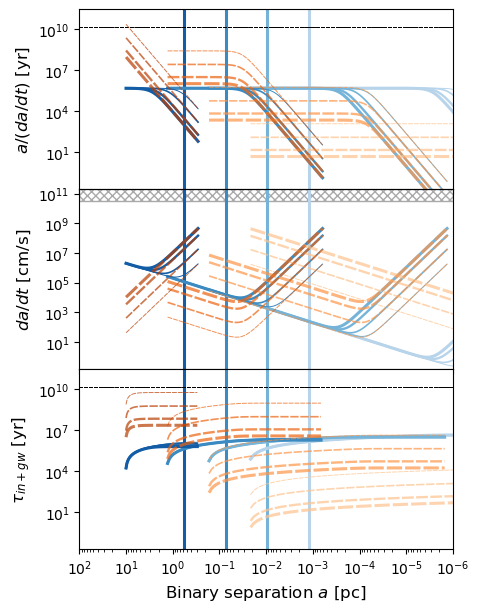

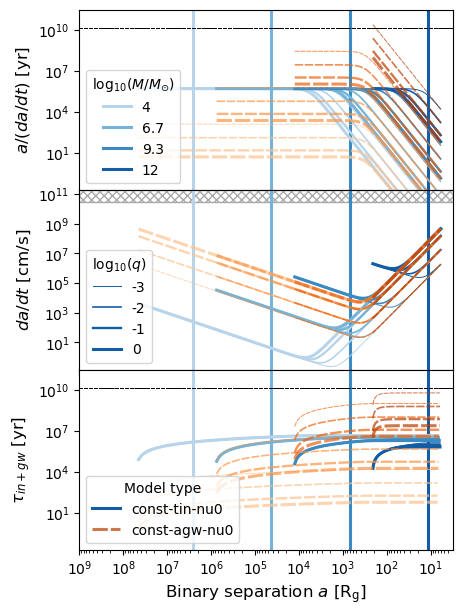

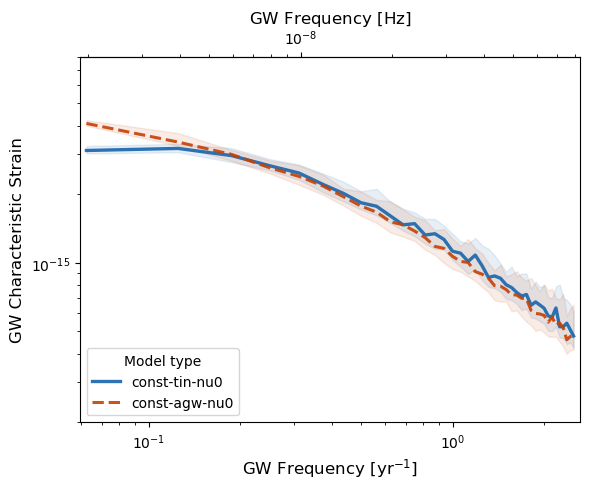

In [76]:
cherry_pick_newhard_sams(plot_stargas=False, plot_rgw_stargas=False)

## figure 4: rgw9var for const-tin-nu0

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
n=0 s.gwb_sam=None
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=11
no plot generated for sam with invalid params:
freqs_to_plot=array([3.16880878e-09, 1.05626959e-08, 3.16880878e-08])
xval=1.25 fid_value=2.5
xval=1.5 fid_value=2.5
n=1 hctot.shape=(40, 100)
xval=1.75 fid_value=2.5
n=2 hctot.shape=(40, 100)
xval=2.0 fid_value=2.5
n=3 hctot.shape=(40, 100)
xval=2.25 fid_value=2.5
n=4 hctot.shape=(40, 100)
xval=2.5 fid_value=2.5
fiducial value 2.5 has index 5 in list of all sams.
n=5 hctot.shape=(40, 100)
xval=2.75 fid_value=2.5
n=6 hctot.shape=(40, 100)
xval=3.0 fid_value=2.5
n=7 hctot.shape=(40, 100)
xval=3.25 fid_value=2.5
n=8 hctot.shape=(40, 100)
xval=3.5 fid_value=2.5
n=9 hctot.shape=(40, 100)
xval=3.75 fid_value=2.5
n=10 

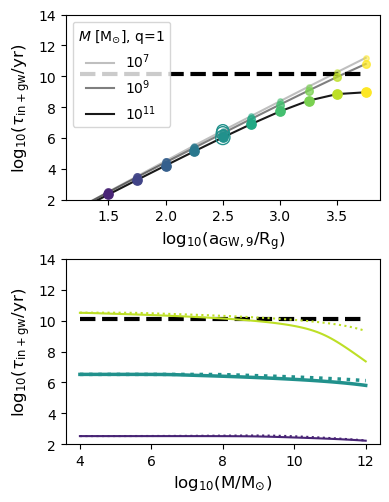

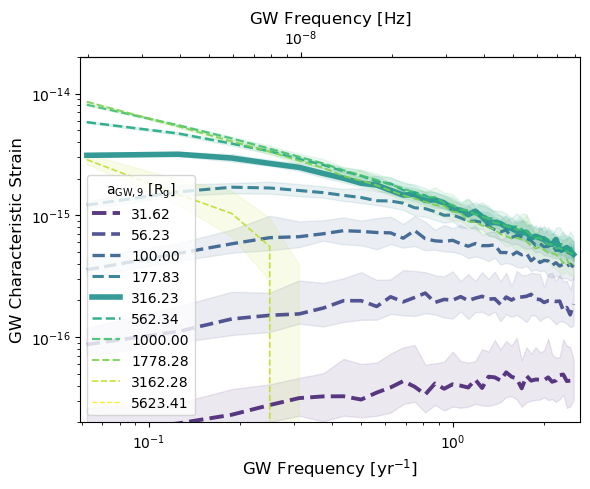

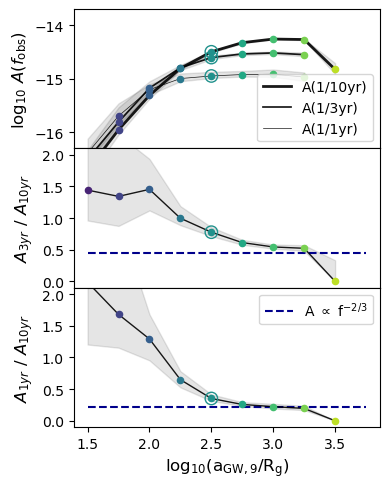

In [86]:
load_and_plot_newhard_sams(_subdir='gensams_nreal100/fid_const-tin', 
                           _fname_type='new_hardening_type0_rgw9var', 
                           _var_type='hard_r_gw_crit_9',_fid_value=2.5,
                           plot_gwb_pars=False,
                           NREALS=100,NLOUD=5,NFREQS=40,skip_dadt_plot=True,
                           dadt_idx_to_plot=np.array([1,5,9]), 
                           _idx_fiducial=5, 
                           skip_gwb_plot=False,skip_tauin_plot=False)

## figure 5: rgw9var for const-agw-nu0

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
n=0 s.gwb_sam=None
n=1 s.gwb_sam=None
n=2 s.gwb_sam=None
n=3 s.gwb_sam=None
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=11
no plot generated for sam with invalid params:
no plot generated for sam with invalid params:
no plot generated for sam with invalid params:
no plot generated for sam with invalid params:
freqs_to_plot=array([3.16880878e-09, 1.05626959e-08, 3.16880878e-08])
xval=1.25 fid_value=2.5
xval=1.5 fid_value=2.5
xval=1.75 fid_value=2.5
xval=2.0 fid_value=2.5
xval=2.25 fid_value=2.5
n=4 hctot.shape=(40, 100)
xval=2.5 fid_value=2.5
fiducial value 2.5 has index 5 in list of all sams.
n=5 hctot.shape=(40, 100)
xval=2.75 fid_value=2.5
n=6 hctot.shape=(40, 100)
xval=3.0 fid_value=2.5
n=7 hctot.shape=(40, 100)
xval=3.2

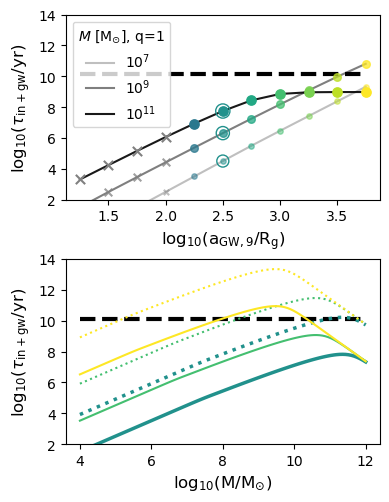

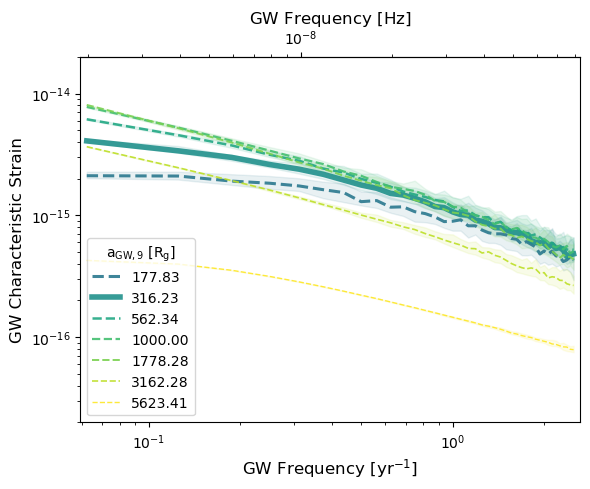

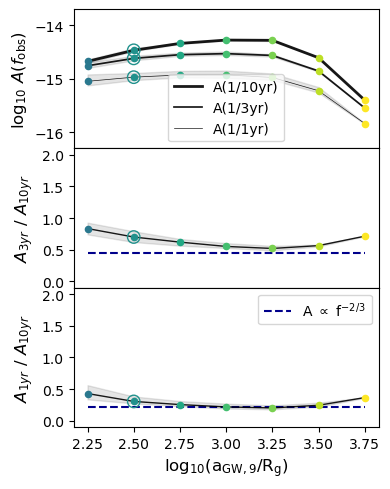

In [88]:
load_and_plot_newhard_sams(_subdir='gensams_nreal100/const-rgw', 
                           _fname_type='new_hardening_type0_rgw9var', 
                           _var_type='hard_r_gw_crit_9',_fid_value=2.5,
                           plot_gwb_pars=False,
                           NREALS=100,NLOUD=5,NFREQS=40,skip_dadt_plot=True,
                           dadt_idx_to_plot= np.array([5,7,10]),
                           _idx_fiducial=5,                           
                           skip_gwb_plot=False,skip_tauin_plot=False)

## figure 6: alphgwvar for const-tin-nu0

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_alphgwvar.pkl
initial length of list sams: len(sams)=9
eliminating alphagw=0.25 sam from list.
eliminating alphagw=0.125 sam from list.
not eliminating alphagw=0.0 sam from list.
not eliminating alphagw=-0.125 sam from list.
not eliminating alphagw=-0.25 sam from list.
not eliminating alphagw=-0.375 sam from list.
not eliminating alphagw=-0.5 sam from list.
eliminating alphagw=-0.625 sam from list.
eliminating alphagw=-0.75 sam from list.
new: len(sams)=5
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=5
freqs_to_plot=array([3.16880878e-09, 1.05626959e-08, 3.16880878e-08])
xval=-0.5 fid_value=-0.25
n=0 hctot.shape=(40, 100)
xval=-0.375 fid_value=-0.25
n=1 hctot.shape=(40, 100)
xval=-0.25 fid_value=-0.25
fiducial value -0.25 has index 2 in 

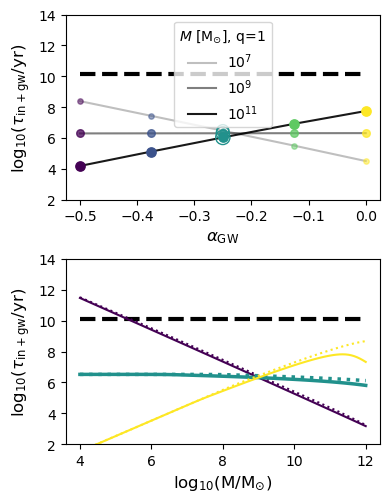

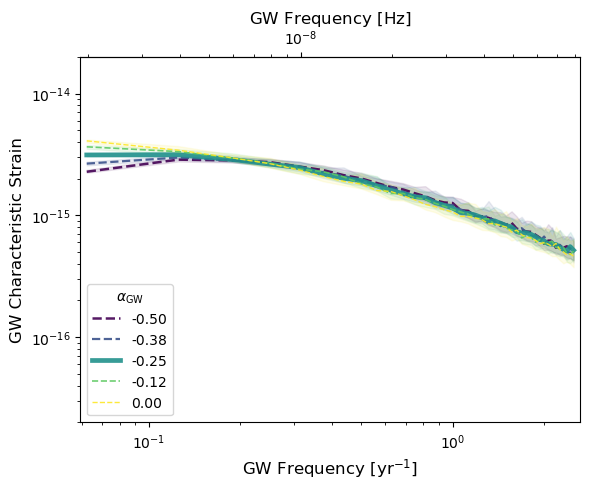

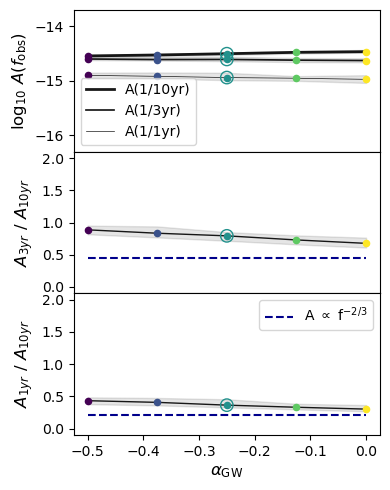

In [89]:
load_and_plot_newhard_sams(_subdir='gensams_nreal100/fid_const-tin', 
                           _fname_type='new_hardening_type0_alphgwvar', 
                           _var_type='hard_alpha_gw_crit',_fid_value=-0.25,
                           plot_gwb_pars=False,
                           dadt_idx_to_plot= np.array([0,2,4]),  
                           _idx_fiducial=2, 
                           NREALS=100,skip_dadt_plot=True,
                           skip_gwb_plot=False,skip_tauin_plot=False,
                           limit_alphgw_range=True)

## figure 7: betagwvar for const-tin-nu0

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_betagwvar.pkl
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=5
freqs_to_plot=array([3.16880878e-09, 1.05626959e-08, 3.16880878e-08])
xval=-0.5 fid_value=0.25
n=0 hctot.shape=(40, 100)
xval=-0.25 fid_value=0.25
n=1 hctot.shape=(40, 100)
xval=0.0 fid_value=0.25
n=2 hctot.shape=(40, 100)
xval=0.25 fid_value=0.25
fiducial value 0.25 has index 3 in list of all sams.
n=3 hctot.shape=(40, 100)
xval=0.5 fid_value=0.25
n=4 hctot.shape=(40, 100)
xvals.shape=(5,) xvals_all.shape=(5,)
fiducial value 0.25 has index 3 in list of valid sams.
amps_list[0].shape=(5, 100) amps_list[0].shape=(5, 100)


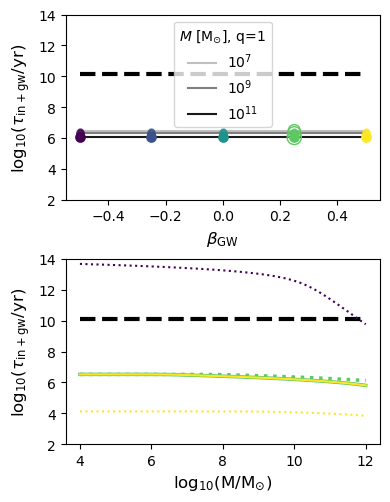

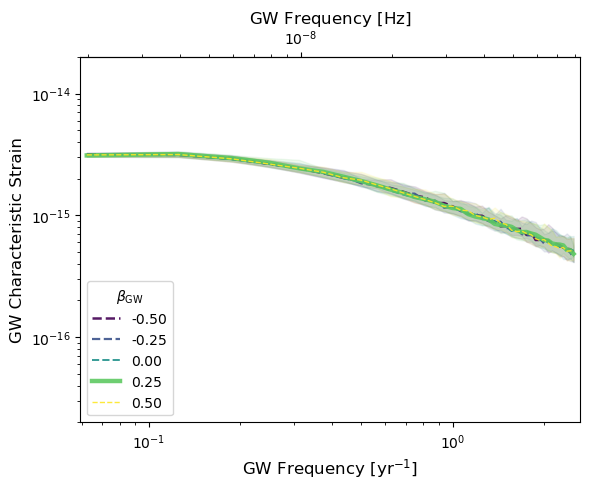

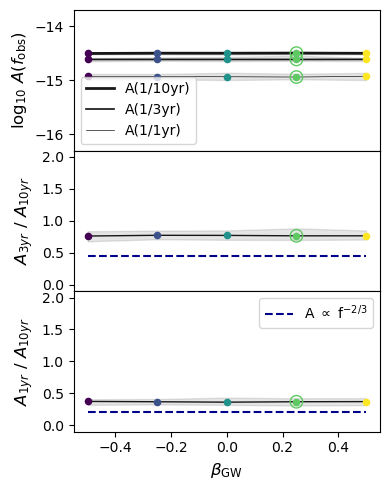

In [90]:
load_and_plot_newhard_sams(_subdir='gensams_nreal100/fid_const-tin', 
                           _fname_type='new_hardening_type0_betagwvar', 
                           _var_type='hard_beta_gw_crit',_fid_value=+0.25,
                           plot_gwb_pars=False,
                           NREALS=100,skip_dadt_plot=True,
                           skip_gwb_plot=False,skip_tauin_plot=False)

## figure 8: nuivar for const-tin-nu0

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_nuivar.pkl
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=7
freqs_to_plot=array([3.16880878e-09, 1.05626959e-08, 3.16880878e-08])
xval=-1.0 fid_value=0
n=0 hctot.shape=(40, 100)
xval=-0.5 fid_value=0
n=1 hctot.shape=(40, 100)
xval=0.0 fid_value=0
fiducial value 0 has index 2 in list of all sams.
n=2 hctot.shape=(40, 100)
xval=0.5 fid_value=0
n=3 hctot.shape=(40, 100)
xval=1.0 fid_value=0
n=4 hctot.shape=(40, 100)
xval=1.5 fid_value=0
n=5 hctot.shape=(40, 100)
xval=2.0 fid_value=0
n=6 hctot.shape=(40, 100)
xvals.shape=(7,) xvals_all.shape=(7,)
fiducial value 0 has index 2 in list of valid sams.
amps_list[0].shape=(7, 100) amps_list[0].shape=(7, 100)


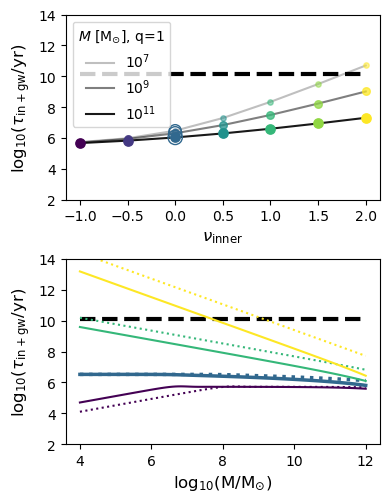

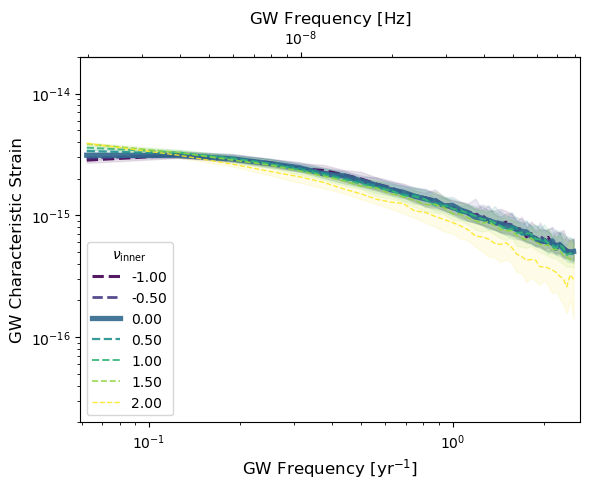

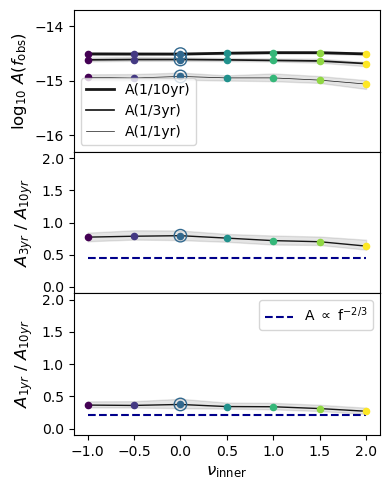

In [91]:
load_and_plot_newhard_sams(_subdir='gensams_nreal100/fid_const-tin', 
                           _fname_type='new_hardening_type0_nuivar', 
                           _var_type='hard_nu_inner',_fid_value=0,
                           plot_gwb_pars=False,
                           dadt_idx_to_plot=np.array([0,2,4,6]), 
                           _idx_fiducial=2,
                           NREALS=100,skip_dadt_plot=True,
                           skip_gwb_plot=False,skip_tauin_plot=False)

## figure 9: rch9var for const-tin-nu0

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rch9var.pkl
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=7
freqs_to_plot=array([3.16880878e-09, 1.05626959e-08, 3.16880878e-08])
xval=-1.0 fid_value=0.0
n=0 hctot.shape=(40, 100)
xval=-0.5 fid_value=0.0
n=1 hctot.shape=(40, 100)
xval=0.0 fid_value=0.0
fiducial value 0.0 has index 2 in list of all sams.
n=2 hctot.shape=(40, 100)
xval=0.49999999999999994 fid_value=0.0
n=3 hctot.shape=(40, 100)
xval=1.0 fid_value=0.0
n=4 hctot.shape=(40, 100)
xval=1.5 fid_value=0.0
n=5 hctot.shape=(40, 100)
xval=2.0 fid_value=0.0
n=6 hctot.shape=(40, 100)
xvals.shape=(7,) xvals_all.shape=(7,)
fiducial value 0.0 has index 2 in list of valid sams.
amps_list[0].shape=(7, 100) amps_list[0].shape=(7, 100)


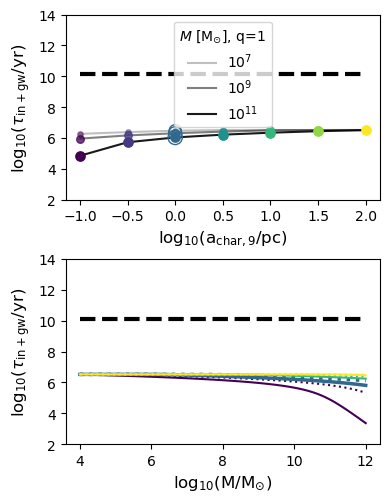

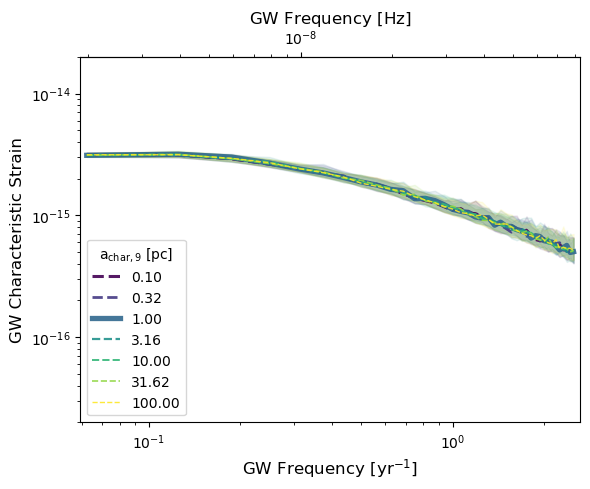

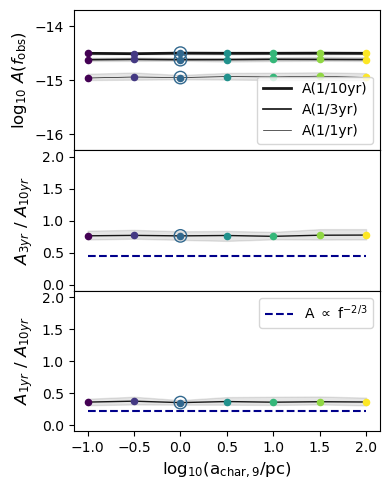

In [92]:
load_and_plot_newhard_sams(_subdir='gensams_nreal100/fid_const-tin', 
                           _fname_type='new_hardening_type0_rch9var', 
                           _var_type='hard_rchar_9',_fid_value=0.0,
                           plot_gwb_pars=False,
                           dadt_idx_to_plot=np.array([0,2,4,6]), 
                           _idx_fiducial=2,
                           NREALS=100,skip_dadt_plot=True,
                           skip_gwb_plot=False,skip_tauin_plot=False)

## figure 10: toutvar for const-tin-nu0

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_toutvar.pkl
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.006035910593714e-08
len(sams)=5
freqs_to_plot=array([3.16880878e-09, 1.05626959e-08, 3.16880878e-08])
xval=-1.0 fid_value=0.0
n=0 hctot.shape=(40, 100)
xval=-0.4999999999999999 fid_value=0.0
n=1 hctot.shape=(40, 100)
xval=0.0 fid_value=0.0
fiducial value 0.0 has index 2 in list of all sams.
n=2 hctot.shape=(40, 100)
xval=0.5 fid_value=0.0
n=3 hctot.shape=(40, 100)
xval=1.0 fid_value=0.0
n=4 hctot.shape=(40, 100)
xvals.shape=(5,) xvals_all.shape=(5,)
fiducial value 0.0 has index 2 in list of valid sams.
amps_list[0].shape=(5, 100) amps_list[0].shape=(5, 100)


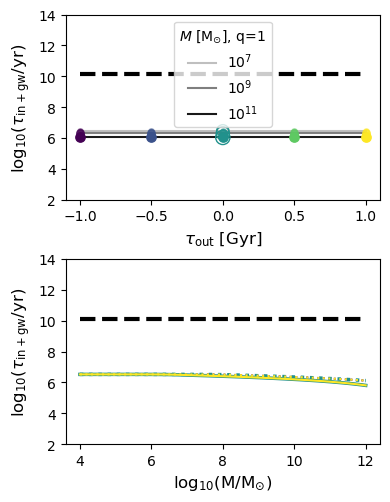

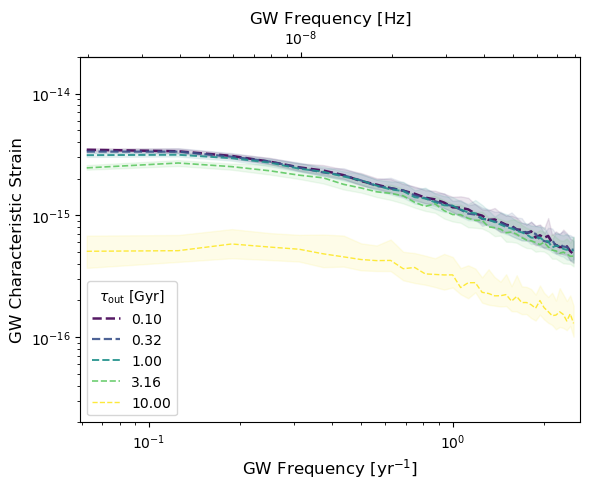

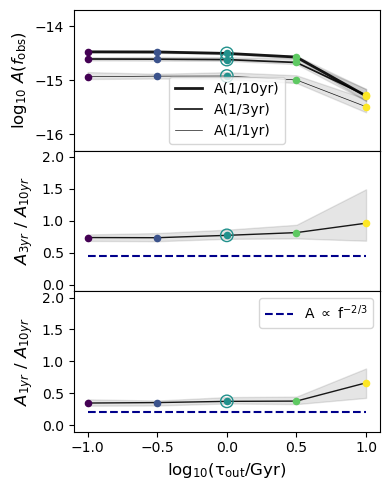

In [87]:
load_and_plot_newhard_sams(_subdir='gensams_nreal100/fid_const-tin', 
                           _fname_type='new_hardening_type0_toutvar', 
                           _var_type='hard_outer_time',_fid_value=0.0,
                           plot_gwb_pars=False,
                           NREALS=100,skip_dadt_plot=True,
                           skip_gwb_plot=False,skip_tauin_plot=False)

## figure 11:

unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
17:19:30 WARNING : found rgw_crit>=rchar. Setting to rchar for these binaries with no inner phase. [hardening.py:dadt]
unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
17:19:53 WARNING : found rgw_crit>=rchar. Setting to rchar for these binaries with no inner phase. [hardening.py:dadt]
unpickling SAM data: test_sam_nfreqs40_nreals100_nloud5_new_hardening_type0_rgw9var.pkl
17:20:16 WARNING : found rgw_crit<=risco. Setting to risco for these binaries with no GW phase. [hardening.py:dadt]
17:20:37 INFO : len(sam_data)=3 [compare_sams.py:plot_dadt]
fpath='/Users/lblecha/nanograv/gensams'
freq_min=1.87795904075655e-09 freq_max=8.302555759134223e-08
_freqs.min()=1.976798990270053e-09 _freqs.max()=7.907195961080212e-08
_freqs_edges.min()=9.883994951350264e-10 _freqs_edges.max()=8.0

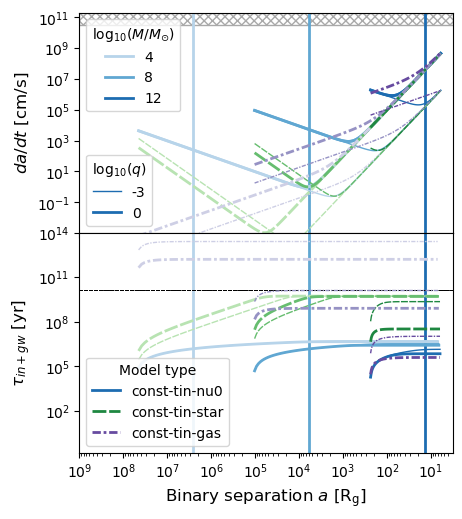

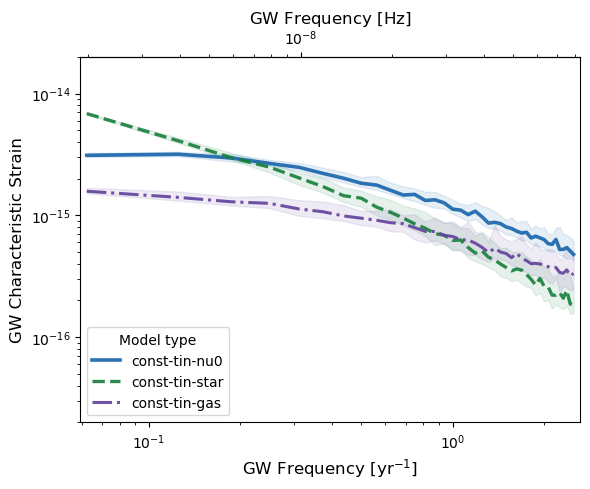

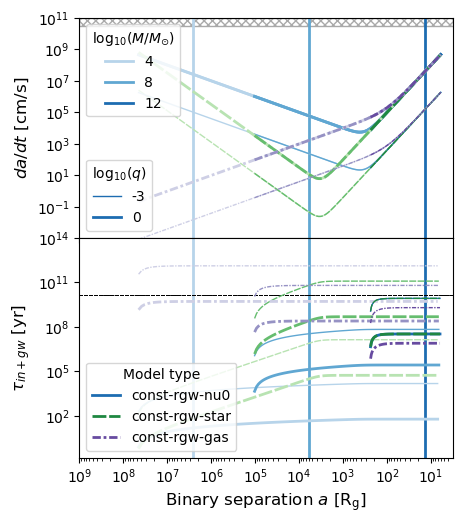

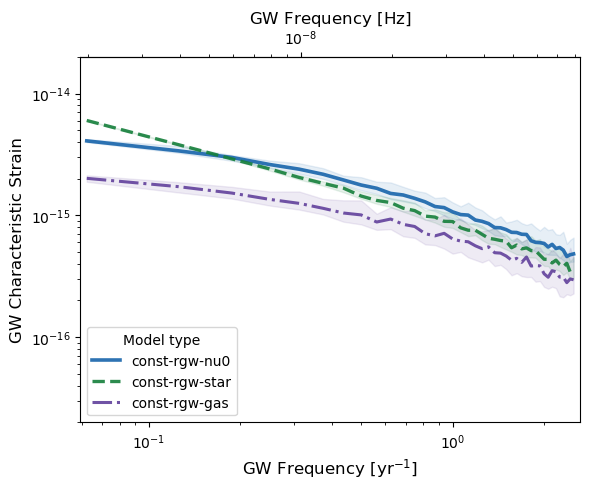

In [104]:
cherry_pick_newhard_sams(plot_fid_rgw=False)